In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "D:\\IMC Prosperity 4\\imc-prosperity-4\\data\\round4-data\\"  # adjust if needed

prices = pd.concat([
    pd.read_csv(DATA_DIR + f'prices_round_4_day_{d}.csv', sep=';')
    for d in [1, 2, 3]], ignore_index=True)

trades = pd.concat([
    pd.read_csv(DATA_DIR + f'trades_round_4_day_{d}.csv', sep=';').assign(day=d)
    for d in [1, 2, 3]], ignore_index=True)

prices['global_ts'] = (prices['day'] - 1) * 1_000_000 + prices['timestamp']
trades['global_ts'] = (trades['day'] - 1) * 1_000_000 + trades['timestamp']

PRODUCTS = sorted(prices['product'].unique())
MARKS    = sorted(set(trades['buyer'].unique()) | set(trades['seller'].unique()))
CORE     = ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']
VEV_OPTS = sorted([p for p in PRODUCTS if p.startswith('VEV_')])

print(f"Price rows : {len(prices):,}")
print(f"Trade rows : {len(trades):,}")
print(f"Products   : {PRODUCTS}")
print(f"Marks      : {MARKS}")

Price rows : 360,000
Trade rows : 4,281
Products   : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Marks      : ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']


## 1. Core Asset Mid Prices

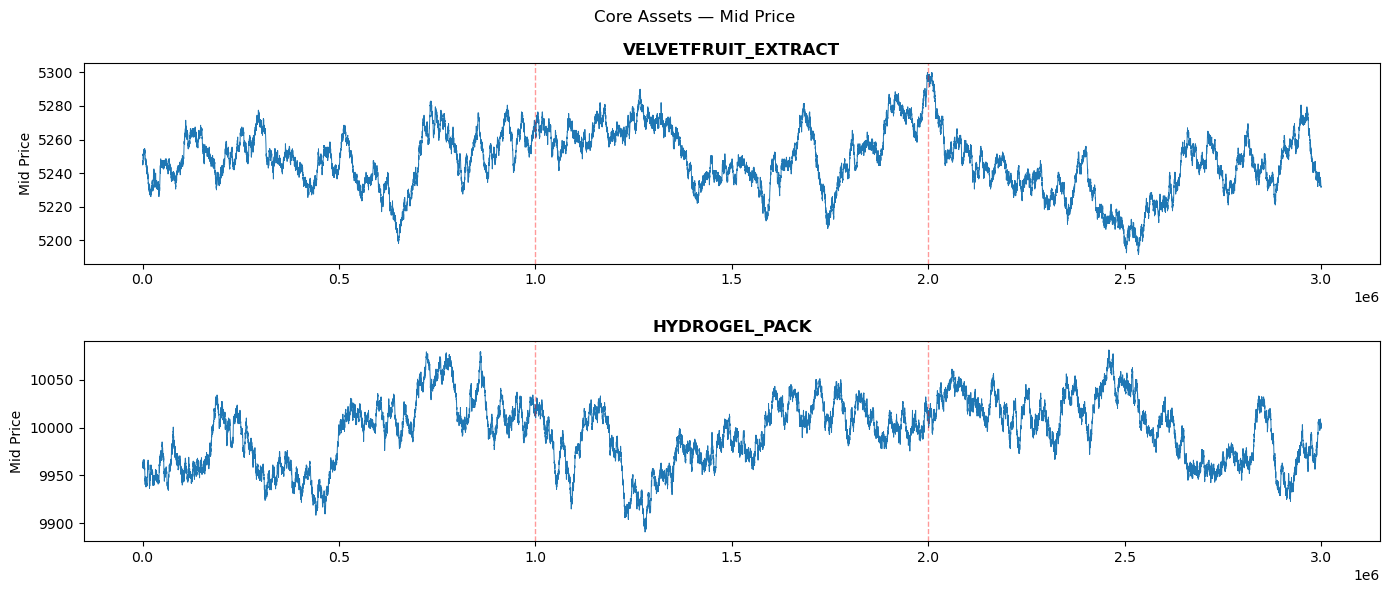

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, prod in zip(axes, CORE):
    df = prices[prices['product'] == prod].sort_values('global_ts')
    ax.plot(df['global_ts'], df['mid_price'], lw=0.7)
    ax.set_title(prod, fontweight='bold')
    ax.set_ylabel('Mid Price')
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color='red', alpha=0.4, ls='--', lw=1, label='day boundary')
plt.suptitle('Core Assets — Mid Price', fontsize=12)
plt.tight_layout()
plt.show()

## 2. VEV Option Contracts — Mid Price by Strike

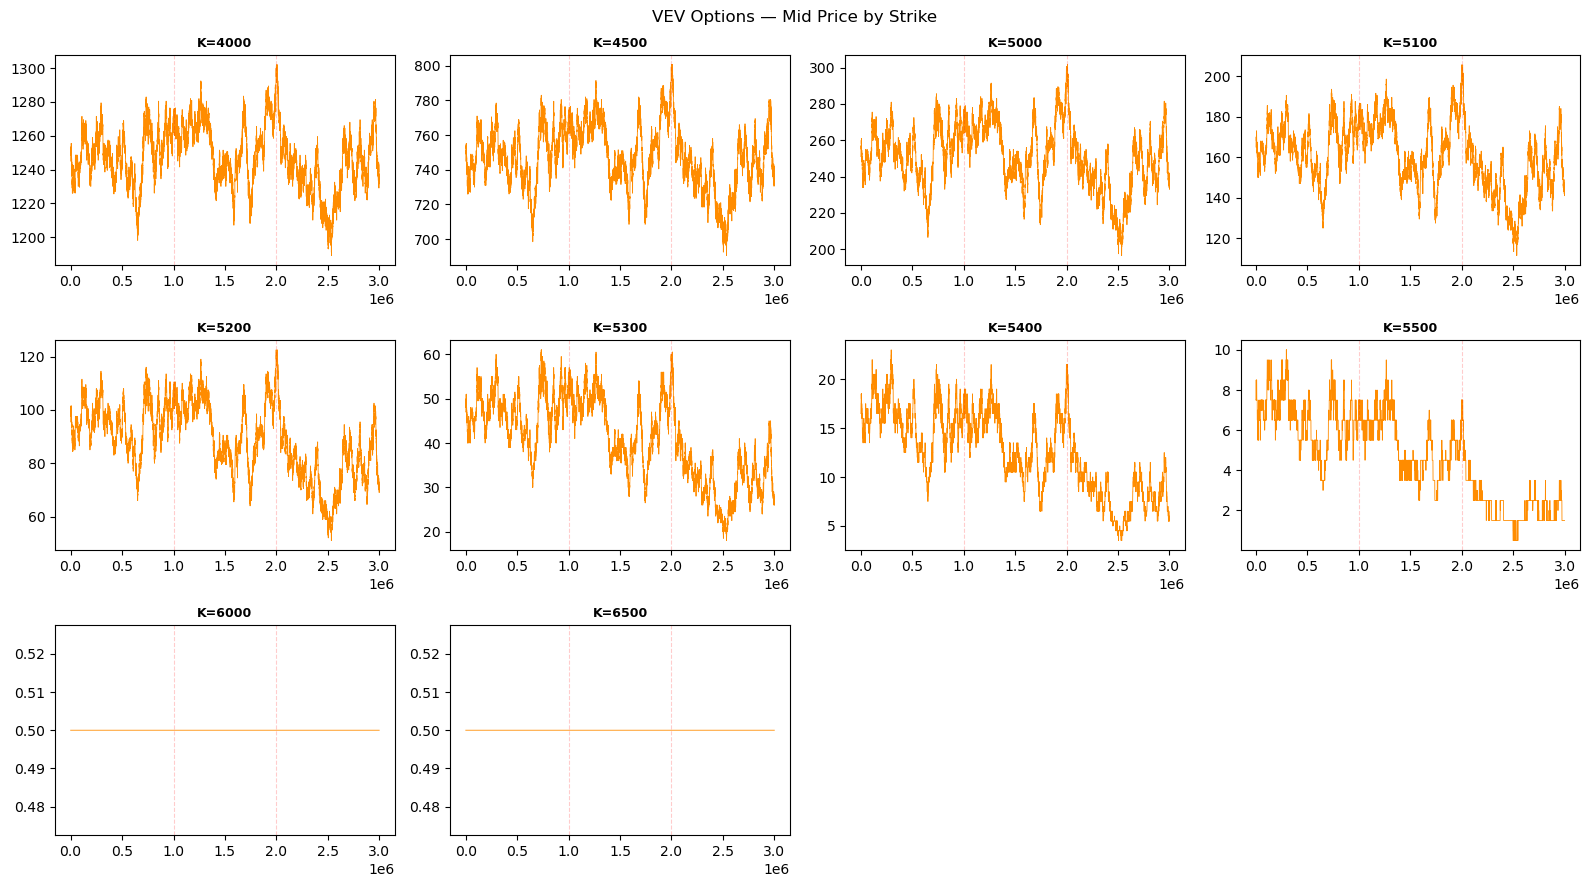

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
for i, prod in enumerate(VEV_OPTS):
    df = prices[prices['product'] == prod].sort_values('global_ts')
    axes[i].plot(df['global_ts'], df['mid_price'], lw=0.6, color='darkorange')
    axes[i].set_title('K=' + prod.replace('VEV_', ''), fontsize=9, fontweight='bold')
    for d in [1, 2]:
        axes[i].axvline(d * 1_000_000, color='red', alpha=0.2, ls='--', lw=0.8)
for j in range(len(VEV_OPTS), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('VEV Options — Mid Price by Strike', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Price Statistics & Stationarity (ADF)

In [9]:
rows = []
for prod in PRODUCTS:
    df = prices[prices['product'] == prod]['mid_price'].dropna()
    df = df[df > 0]
    if len(df) < 50:
        continue
    try:
        pval = adfuller(df, autolag='AIC')[1]
        beh  = 'MEAN-REVERTING' if pval < 0.05 else 'DRIFTING'
    except:
        pval, beh = float('nan'), 'N/A'
    rows.append({
        'product': prod,
        'mean': df.mean(), 'std': df.std(),
        'cv_%': df.std() / df.mean() * 100,
        'adf_p': pval, 'behaviour': beh
    })

stats_df = pd.DataFrame(rows).set_index('product')
print(stats_df.round(4).to_string())

                          mean      std     cv_%   adf_p       behaviour
product                                                                 
HYDROGEL_PACK        9994.6543  34.6233   0.3464  0.0001  MEAN-REVERTING
VELVETFRUIT_EXTRACT  5247.6487  18.0771   0.3445  0.0003  MEAN-REVERTING
VEV_4000             1247.6566  18.1013   1.4508  0.0003  MEAN-REVERTING
VEV_4500              747.6568  18.0924   2.4199  0.0003  MEAN-REVERTING
VEV_5000              251.1446  17.4555   6.9504  0.0004  MEAN-REVERTING
VEV_5100              160.8633  16.1274  10.0255  0.0009  MEAN-REVERTING
VEV_5200               88.9935  13.3470  14.9977  0.0046  MEAN-REVERTING
VEV_5300               41.1763   9.1430  22.2046  0.0215  MEAN-REVERTING
VEV_5400               12.6298   4.1493  32.8535  0.0246  MEAN-REVERTING
VEV_5500                4.7078   2.2053  46.8427  0.0335  MEAN-REVERTING
VEV_6000                0.5000   0.0000   0.0000     NaN             N/A
VEV_6500                0.5000   0.0000   0.0000   

## 4. Bid-Ask Spread

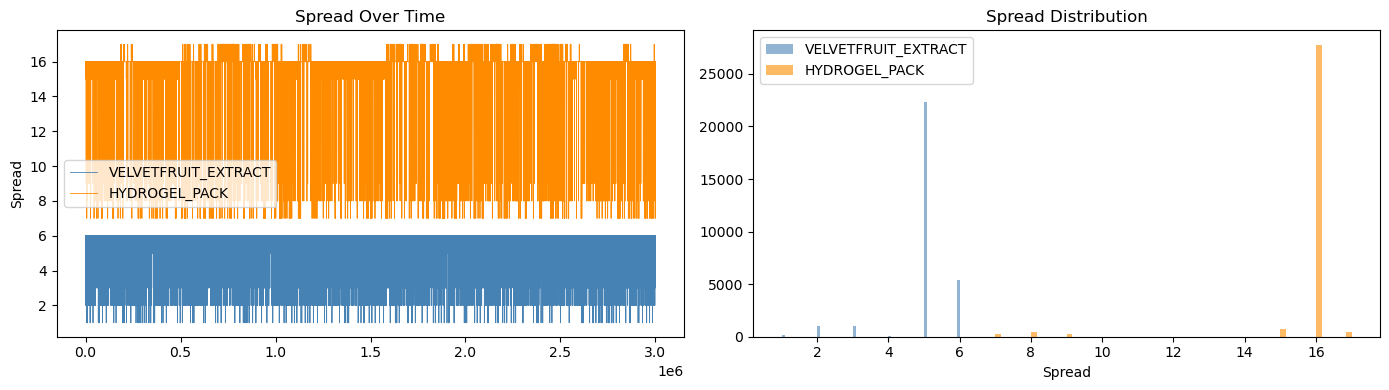

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
clr = {'VELVETFRUIT_EXTRACT': 'steelblue', 'HYDROGEL_PACK': 'darkorange'}
for prod in CORE:
    df = prices[prices['product'] == prod].copy().sort_values('global_ts')
    df['spread'] = df['ask_price_1'] - df['bid_price_1']
    axes[0].plot(df['global_ts'], df['spread'], lw=0.6, label=prod, color=clr[prod])
    axes[1].hist(df['spread'].dropna(), bins=60, alpha=0.6, label=prod, color=clr[prod])
axes[0].set_title('Spread Over Time'); axes[0].set_ylabel('Spread'); axes[0].legend()
axes[1].set_title('Spread Distribution'); axes[1].set_xlabel('Spread'); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. VEV Options — Intrinsic vs Time Value

 strike  mean_opt  mean_spot  mean_intrinsic  mean_tv
   4000   1247.66    5247.65         1247.65     0.01
   4500    747.66    5247.65          747.65     0.01
   5000    251.14    5247.65          247.65     3.50
   5100    160.86    5247.65          147.65    13.21
   5200     88.99    5247.65           47.66    41.33
   5300     41.18    5247.65            0.00    41.18
   5400     12.63    5247.65            0.00    12.63
   5500      4.71    5247.65            0.00     4.71
   6000      0.50    5247.65            0.00     0.50
   6500      0.50    5247.65            0.00     0.50


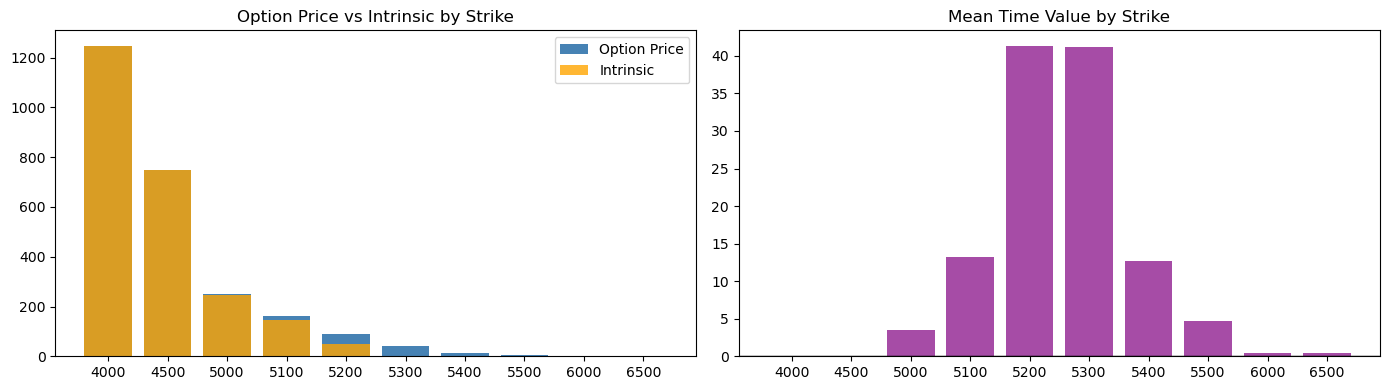

In [11]:
spot_df = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'][['global_ts','mid_price']].rename(columns={'mid_price':'spot'})

rows = []
for prod in VEV_OPTS:
    strike = int(prod.replace('VEV_', ''))
    df = prices[prices['product'] == prod][['global_ts','mid_price']].rename(columns={'mid_price':'opt'})
    m  = pd.merge_asof(df.sort_values('global_ts'), spot_df.sort_values('global_ts'), on='global_ts', direction='nearest')
    m['strike']    = strike
    m['intrinsic'] = np.maximum(m['spot'] - strike, 0)
    m['time_val']  = m['opt'] - m['intrinsic']
    rows.append(m)

vev_df = pd.concat(rows, ignore_index=True)
summary = vev_df.groupby('strike').agg(
    mean_opt=('opt','mean'), mean_spot=('spot','mean'),
    mean_intrinsic=('intrinsic','mean'), mean_tv=('time_val','mean')).reset_index()

print(summary.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = summary['strike'].astype(str)
axes[0].bar(x, summary['mean_opt'],       label='Option Price', color='steelblue')
axes[0].bar(x, summary['mean_intrinsic'], label='Intrinsic',    color='orange', alpha=0.8)
axes[0].set_title('Option Price vs Intrinsic by Strike'); axes[0].legend()
axes[1].bar(x, summary['mean_tv'], color='purple', alpha=0.7)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Mean Time Value by Strike')
plt.tight_layout(); plt.show()

## 6. Mark Trader Analysis

Enrich each trade with the contemporaneous mid price, then estimate PnL for each Mark.

In [12]:
mid = prices[['global_ts','product','mid_price']].rename(columns={'product':'symbol'}).sort_values('global_ts')

parts = []
for sym in trades['symbol'].unique():
    t = trades[trades['symbol'] == sym].sort_values('global_ts')
    m = mid[mid['symbol'] == sym].sort_values('global_ts')
    if len(m) == 0:
        continue
    merged = pd.merge_asof(t, m[['global_ts','mid_price']], on='global_ts', direction='nearest')
    parts.append(merged)

te = pd.concat(parts, ignore_index=True)
te['buy_pnl_evt']  = (te['mid_price'] - te['price']) * te['quantity']   # positive = bought below mid
te['sell_pnl_evt'] = (te['price'] - te['mid_price']) * te['quantity']   # positive = sold above mid

print(f"Enriched trades: {len(te):,}")
te[['timestamp','buyer','seller','symbol','price','mid_price','buy_pnl_evt']].head(8)

Enriched trades: 4,281


,timestamp,buyer,seller,symbol,price,mid_price,buy_pnl_evt
0,4500,Mark 01,Mark 22,VEV_5400,18.0,18.5,1.0
1,9600,Mark 01,Mark 22,VEV_5400,16.0,17.0,4.0
2,14800,Mark 01,Mark 22,VEV_5400,14.0,15.0,4.0
3,16700,Mark 01,Mark 22,VEV_5400,14.0,14.5,1.0
4,40400,Mark 01,Mark 22,VEV_5400,14.0,14.5,2.0
5,43400,Mark 01,Mark 22,VEV_5400,13.0,14.0,5.0
6,50700,Mark 01,Mark 22,VEV_5400,16.0,16.5,2.5
7,52800,Mark 01,Mark 22,VEV_5400,16.0,16.5,1.5


## 7. Estimated PnL per Mark

         buy_pnl  sell_pnl  total_pnl
Mark 14  25171.0   24726.0    49897.0
Mark 01   6300.0    3675.0     9975.0
Mark 49    167.0     694.5      861.5
Mark 67  -1156.5       0.0    -1156.5
Mark 22    310.5   -2240.0    -1929.5
Mark 55  -8109.5   -8113.0   -16222.5
Mark 38 -20540.0  -20885.0   -41425.0


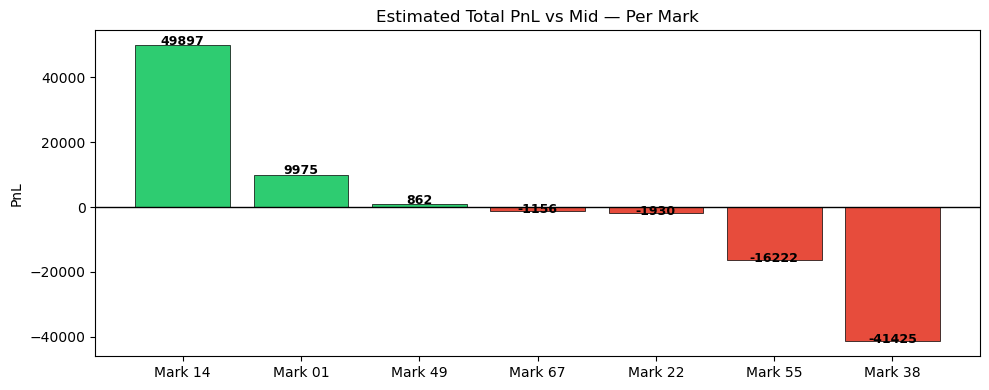

In [22]:
buy_pnl  = te.groupby('buyer')['buy_pnl_evt'].sum().rename('buy_pnl')
sell_pnl = te.groupby('seller')['sell_pnl_evt'].sum().rename('sell_pnl')
te.groupby(['buyer','symbol'])['buy_pnl_evt'].sum().unstack().fillna(0)
te.groupby(['seller','symbol'])['sell_pnl_evt'].sum().unstack().fillna(0)
mark_pnl = pd.DataFrame({'buy_pnl': buy_pnl, 'sell_pnl': sell_pnl}).fillna(0)
mark_pnl['total_pnl'] = mark_pnl['buy_pnl'] + mark_pnl['sell_pnl']
mark_pnl = mark_pnl.sort_values('total_pnl', ascending=False)

print(mark_pnl.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in mark_pnl['total_pnl']]
bars = ax.bar(mark_pnl.index, mark_pnl['total_pnl'], color=colors, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_title('Estimated Total PnL vs Mid — Per Mark', fontsize=12)
ax.set_ylabel('PnL')
for bar, val in zip(bars, mark_pnl['total_pnl']):
    offset = 200 if val >= 0 else -600
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f"{val:.0f}", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

In [23]:
buy_by_sym  = te.groupby(['buyer','symbol'])['buy_pnl_evt'].sum().unstack().fillna(0)
sell_by_sym = te.groupby(['seller','symbol'])['sell_pnl_evt'].sum().unstack().fillna(0)

print("=== BUY PnL per Mark per Symbol ===")
print(buy_by_sym.round(0).to_string())
print()
print("=== SELL PnL per Mark per Symbol ===")
print(sell_by_sym.round(0).to_string())
print()
print("=== TOTAL PnL per Mark per Symbol ===")
print((buy_by_sym + sell_by_sym).round(0).to_string())

=== BUY PnL per Mark per Symbol ===
symbol   HYDROGEL_PACK  VELVETFRUIT_EXTRACT  VEV_4000  VEV_4500  VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  VEV_5500  VEV_6000  VEV_6500
buyer                                                                                                                                          
Mark 01            0.0               3670.0       0.0       0.0       0.0       0.0      34.0     399.0     544.0     548.0     552.0     552.0
Mark 14        15876.0               4262.0    4796.0       0.0       0.0       0.0     122.0      80.0      22.0      14.0       0.0       0.0
Mark 22          171.0                 98.0      16.0      12.0       4.0       4.0       3.0       2.0       0.0       0.0       0.0       0.0
Mark 38       -16244.0                  0.0   -4279.0     -10.0      -3.0      -2.0      -2.0      -0.0       0.0       0.0       0.0       0.0
Mark 49            0.0                167.0       0.0       0.0       0.0       0.0       0.0       

## 8. Average Edge per Trade

         avg_buy_edge  avg_sell_edge  buy_trades  sell_trades  avg_edge
Mark 14        22.335         23.661        1127       1045.0    22.998
Mark 01         3.940         15.061        1599        244.0     9.501
Mark 49         9.824          6.614          17        105.0     8.219
Mark 22         7.393         -1.453          42       1542.0     2.970
Mark 67        -7.009          0.000         165          0.0    -3.505
Mark 55       -13.561        -13.522         598        600.0   -13.541
Mark 38       -28.022        -28.034         733        745.0   -28.028


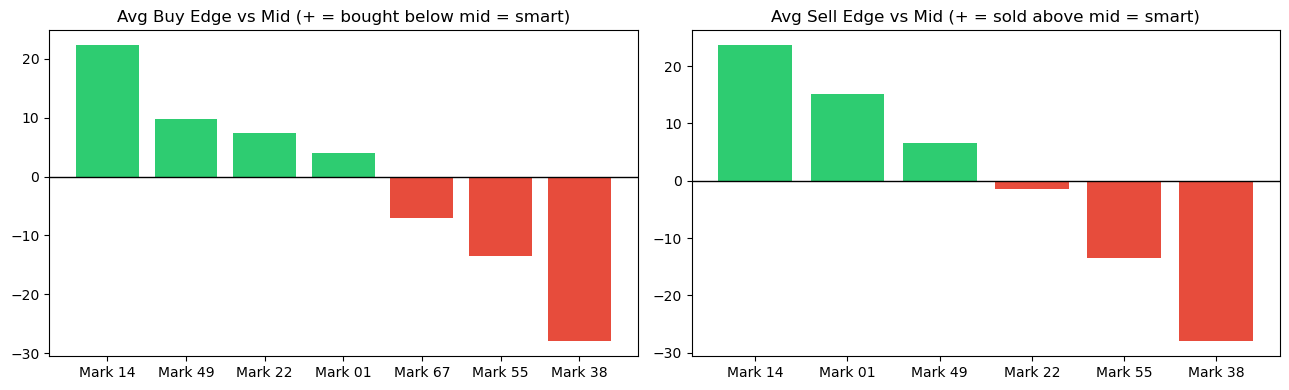

In [15]:
buy_edge  = te.groupby('buyer')['buy_pnl_evt'].mean().rename('avg_buy_edge')
sell_edge = te.groupby('seller')['sell_pnl_evt'].mean().rename('avg_sell_edge')
buy_cnt   = te.groupby('buyer').size().rename('buy_trades')
sell_cnt  = te.groupby('seller').size().rename('sell_trades')

edge_df = pd.concat([buy_edge, sell_edge, buy_cnt, sell_cnt], axis=1).fillna(0)
edge_df['avg_edge'] = (edge_df['avg_buy_edge'] + edge_df['avg_sell_edge']) / 2
edge_df = edge_df.sort_values('avg_edge', ascending=False)
print(edge_df.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(buy_edge.sort_values(ascending=False).index,
            buy_edge.sort_values(ascending=False),
            color=['#2ecc71' if v>0 else '#e74c3c' for v in buy_edge.sort_values(ascending=False)])
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Avg Buy Edge vs Mid (+ = bought below mid = smart)')

axes[1].bar(sell_edge.sort_values(ascending=False).index,
            sell_edge.sort_values(ascending=False),
            color=['#2ecc71' if v>0 else '#e74c3c' for v in sell_edge.sort_values(ascending=False)])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Avg Sell Edge vs Mid (+ = sold above mid = smart)')
plt.tight_layout(); plt.show()

## 9. Cumulative PnL per Mark Over Time

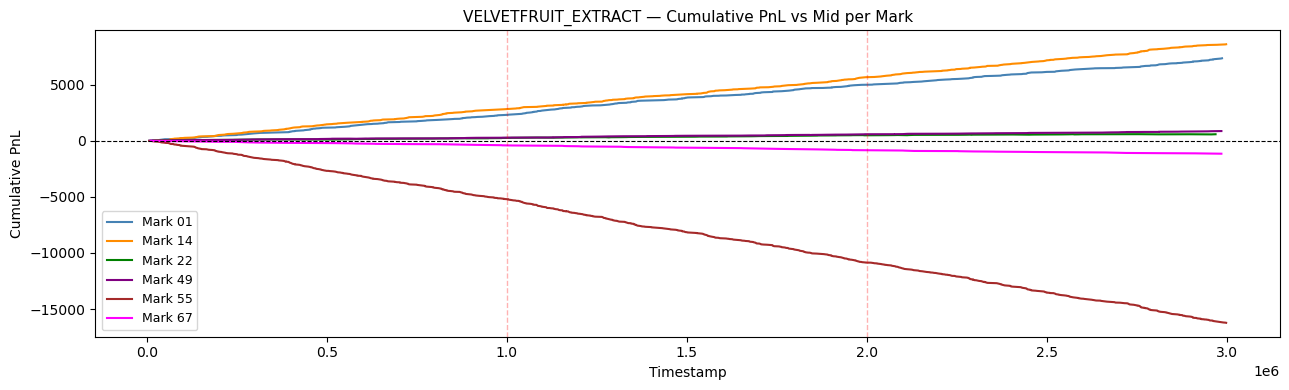

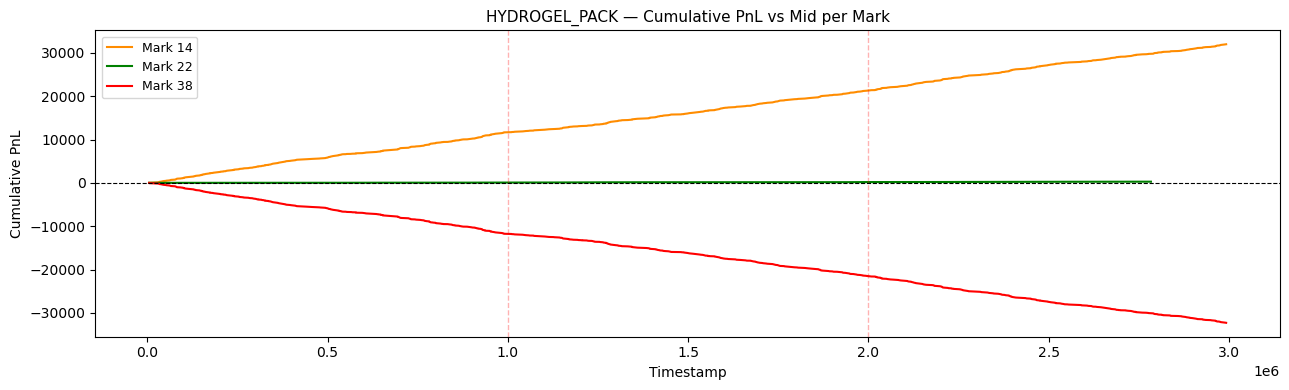

In [16]:
palette = ['steelblue','darkorange','green','red','purple','brown','magenta']

for sym in CORE:
    t_sym = te[te['symbol'] == sym].sort_values('global_ts')
    fig, ax = plt.subplots(figsize=(13, 4))
    for mark, color in zip(MARKS, palette):
        b = t_sym[t_sym['buyer']  == mark][['global_ts','buy_pnl_evt']].rename(columns={'buy_pnl_evt':'pnl'})
        s = t_sym[t_sym['seller'] == mark][['global_ts','sell_pnl_evt']].rename(columns={'sell_pnl_evt':'pnl'})
        ev = pd.concat([b, s]).sort_values('global_ts')
        if len(ev) == 0:
            continue
        ev['cum'] = ev['pnl'].cumsum()
        ax.plot(ev['global_ts'], ev['cum'], lw=1.5, label=mark, color=color)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color='red', alpha=0.3, ls='--', lw=1)
    ax.set_title(sym + ' — Cumulative PnL vs Mid per Mark', fontsize=11)
    ax.set_ylabel('Cumulative PnL'); ax.set_xlabel('Timestamp')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

In [26]:
m14 = trades[(trades['buyer']=='Mark 14') | (trades['seller']=='Mark 14')].copy()

top = prices[['global_ts','product','bid_price_1','ask_price_1']].rename(
    columns={'product':'symbol'}).sort_values('global_ts')

m14 = m14.sort_values('global_ts')
m14 = pd.merge_asof(m14, top, on='global_ts', by='symbol', direction='nearest')
m14['m14_side'] = np.where(m14['buyer']=='Mark 14', 'BUY', 'SELL')

def role(r):
    if r['m14_side']=='BUY':
        if r['price'] == r['bid_price_1']: return 'MAKER'   # their bid got hit
        if r['price'] == r['ask_price_1']: return 'TAKER'   # they lifted an ask
    else:
        if r['price'] == r['ask_price_1']: return 'MAKER'   # their ask got hit
        if r['price'] == r['bid_price_1']: return 'TAKER'   # they sold into a bid
    return 'INSIDE'

m14['role'] = m14.apply(role, axis=1)
print(m14['role'].value_counts())
print()
print(m14.groupby(['symbol','role']).size().unstack(fill_value=0))

role
MAKER     2169
INSIDE       3
Name: count, dtype: int64

role                 INSIDE  MAKER
symbol                            
HYDROGEL_PACK             0   1003
VELVETFRUIT_EXTRACT       0    647
VEV_4000                  0    439
VEV_5200                  0     33
VEV_5300                  2     28
VEV_5400                  1     12
VEV_5500                  0      7


## 10. Counterparty Volume Matrix

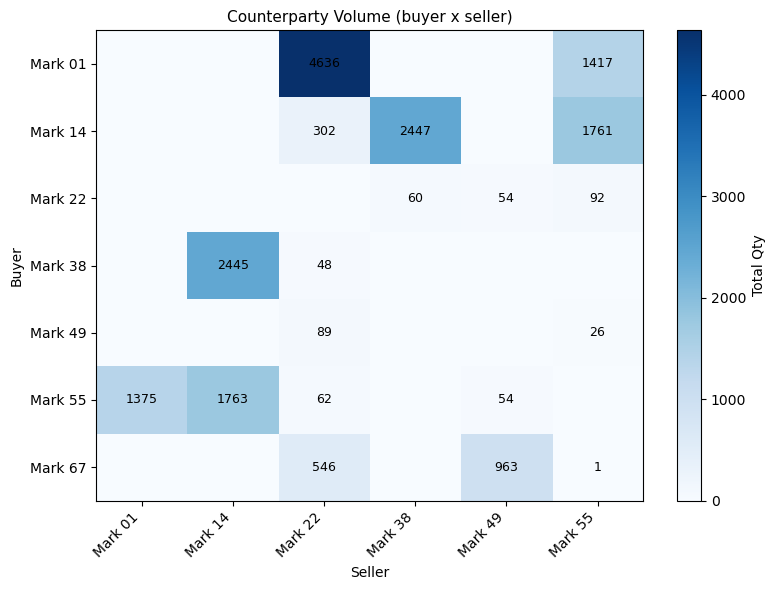

In [17]:
cp = trades.groupby(['buyer','seller'])['quantity'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cp.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(cp.columns))); ax.set_xticklabels(cp.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cp.index)));   ax.set_yticklabels(cp.index)
ax.set_title('Counterparty Volume (buyer x seller)', fontsize=11)
ax.set_xlabel('Seller'); ax.set_ylabel('Buyer')
plt.colorbar(im, ax=ax, label='Total Qty')
for i in range(len(cp.index)):
    for j in range(len(cp.columns)):
        val = cp.values[i, j]
        if val > 0:
            ax.text(j, i, str(int(val)), ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 11. Mark Activity on VEV Options by Strike

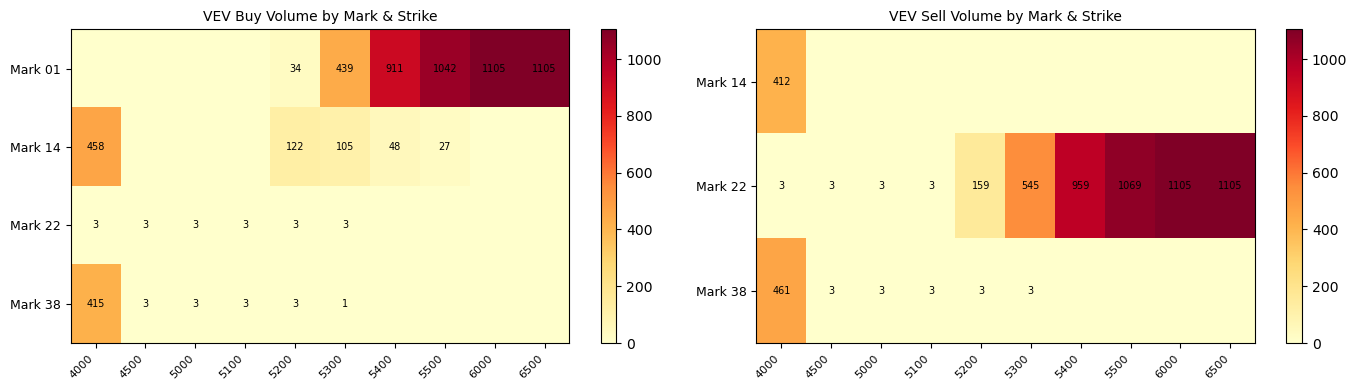

In [18]:
vev_t = te[te['symbol'].str.startswith('VEV_')].copy()
vev_t['strike'] = vev_t['symbol'].str.replace('VEV_','').astype(int)

buy_h  = vev_t.groupby(['buyer','strike'])['quantity'].sum().unstack(fill_value=0)
sell_h = vev_t.groupby(['seller','strike'])['quantity'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in [(axes[0], buy_h,'Buy Volume'),(axes[1], sell_h,'Sell Volume')]:
    im = ax.imshow(data.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(data.columns)));  ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)));    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_title('VEV ' + title + ' by Mark & Strike', fontsize=10)
    plt.colorbar(im, ax=ax)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i,j]
            if val > 0:
                ax.text(j, i, str(int(val)), ha='center', va='center', fontsize=7)
plt.tight_layout(); plt.show()

## 12. Predictive Edge — Does a Mark Trade Predict Future Mid Movement?

In [19]:
LOOK_AHEAD = 500  # ticks

results = []
for sym in CORE:
    mid_sym = prices[prices['product']==sym][['global_ts','mid_price']].sort_values('global_ts').reset_index(drop=True)
    t_sym   = te[te['symbol']==sym].sort_values('global_ts')
    for _, row in t_sym.iterrows():
        future = mid_sym[mid_sym['global_ts'] >= row['global_ts'] + LOOK_AHEAD]
        if len(future) == 0:
            continue
        fwd = future.iloc[0]['mid_price'] - row['mid_price']
        results.append({'symbol': sym, 'buyer': row['buyer'], 'seller': row['seller'], 'fwd_move': fwd})

pred = pd.DataFrame(results)

print(f"=== Buyer predictive edge (+ = mid rose after their buy) ===")
print(pred.groupby('buyer')['fwd_move'].mean().sort_values(ascending=False).round(3).to_string())
print()
print(f"=== Seller predictive edge (+ = mid fell after their sell) ===")
neg = pred.copy(); neg['fwd_move'] = -neg['fwd_move']
print(neg.groupby('seller')['fwd_move'].mean().sort_values(ascending=False).round(3).to_string())

=== Buyer predictive edge (+ = mid rose after their buy) ===
buyer
Mark 67    1.945
Mark 01    0.290
Mark 55    0.199
Mark 14    0.031
Mark 38   -0.119
Mark 22   -1.097
Mark 49   -1.824

=== Seller predictive edge (+ = mid fell after their sell) ===
seller
Mark 01    0.002
Mark 14    0.001
Mark 38   -0.012
Mark 55   -0.052
Mark 22   -1.665
Mark 49   -1.819


## 13. Summary

In [20]:
print("="*55)
print("MARK RANKING (estimated PnL vs mid)")
print("="*55)
print(mark_pnl[['total_pnl']].round(1).to_string())
print()
print("="*55)
print("MARKS TO FOLLOW (best avg edge per trade)")
print("="*55)
for m, v in edge_df['avg_edge'].nlargest(3).items():
    print(f"  {m}: {v:+.3f}")
print()
print("MARKS TO FADE (worst avg edge = consistently overpay/undersell)")
for m, v in edge_df['avg_edge'].nsmallest(2).items():
    print(f"  {m}: {v:+.3f}")

MARK RANKING (estimated PnL vs mid)
         total_pnl
Mark 14    49897.0
Mark 01     9975.0
Mark 49      861.5
Mark 67    -1156.5
Mark 22    -1929.5
Mark 55   -16222.5
Mark 38   -41425.0

MARKS TO FOLLOW (best avg edge per trade)
  Mark 14: +22.998
  Mark 01: +9.501
  Mark 49: +8.219

MARKS TO FADE (worst avg edge = consistently overpay/undersell)
  Mark 38: -28.028
  Mark 55: -13.541
